In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D


Data Preprocessed and Saved

In [ ]:
# Read TXT file line by line
sequences = []
with open("all_analysis_data.txt", "r") as f:
    for line in f:
        tokens = line.strip().lower().split()  # lowercase & split
        sequences.append(tokens)

print(f"Total samples: {len(sequences)}")
print(f"Example sequence: {sequences[0][:20]}")  # first 20 tokens of first sample

In [ ]:
def collapse_duplicates(seq):
    if not seq:
        return []
    collapsed = [seq[0]]
    for token in seq[1:]:
        if token != collapsed[-1]:
            collapsed.append(token)
    return collapsed

# Apply to all sequences
sequences = [collapse_duplicates(seq) for seq in sequences]

print(f"Example after collapsing duplicates: {sequences[0][:20]}")


In [ ]:
import csv

with open("all_analysis_data.csv", "w", newline="") as f:
    writer = csv.writer(f)

    for seq in sequences:
        row_text = " ".join(seq)   # convert list -> single string
        writer.writerow([row_text])  # write one-column row


In [ ]:
labels = pd.read_csv("labels.csv", header=None)
df = pd.read_csv("all_analysis_data.csv", header=None)
df.columns = ["API_Calls"]
df["Labels"] = labels
df.head()

In [ ]:
df.duplicated().sum()

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
df.Labels.value_counts()

In [ ]:
df.to_csv("preprocessed_dataset.csv", index=False)

Tokenize dataset

In [31]:
df = pd.read_csv("preprocessed_dataset.csv")
max_words = 800
max_len = 500

X = df.API_Calls

# Create categorical labels
y_cat = df.Labels.astype("category")
# Numeric labels
y = y_cat.cat.codes


tok = Tokenizer(num_words=max_words)
tok.fit_on_texts(X)
print("unique tokens:",len(tok.word_index))
X = tok.texts_to_sequences(X.values)
X = sequence.pad_sequences(X, maxlen=max_len)
print('Shape of data tensor:', X.shape)


unique tokens: 280
Shape of data tensor: (6470, 500)


In [32]:
label_id_to_name = dict(enumerate(y_cat.cat.categories))

# (optional) reverse mapping: class name -> number
label_name_to_id = {v: k for k, v in label_id_to_name.items()}

label_id_to_name

{0: 'Adware',
 1: 'Backdoor',
 2: 'Downloader',
 3: 'Dropper',
 4: 'Spyware',
 5: 'Trojan',
 6: 'Virus',
 7: 'Worms'}

In [33]:
pd.DataFrame.from_dict(label_id_to_name, orient="index", columns=["Class"]) \
  .to_csv("label_mapping.csv")

In [34]:
df_save = pd.DataFrame(X)  # integer token sequences
df_save['Label'] = y           # integer labels

#save tokenize dataset
df_save.to_csv("malware_sequences_int.csv", index=False)

Train Test and Validation Split

In [2]:
df = pd.read_csv("malware_sequences_int.csv")
X = df.drop(columns="Label")
y = df.Label

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, y, test_size=0.25, random_state=42,stratify=y
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.6, random_state=42, stratify=Y_temp
)

# train -> 75%, Val -> 10%, Test -> 15%

Model Build and Train

In [3]:
max_words = 800
max_len = 400

def malware_model(act_func="relu"):
    model = Sequential()
    model.add(Embedding(max_words, 128))
    model.add(SpatialDropout1D(0.1))
    model.add(LSTM(32, dropout=0.1, recurrent_dropout=0.1,
                   return_sequences=True))
    
    model.add(LSTM(32, dropout=0.1))
    model.add(Dense(128, activation=act_func))
    model.add(Dropout(0.1))
    
    model.add(Dense(128, activation=act_func))
    model.add(Dropout(0.1))
    model.add(Dense(8, name='out_layer', activation="softmax"))
    return model

    

In [4]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(Y_train),
    y=Y_train
)

class_weights = dict(enumerate(class_weights))


In [5]:

es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model = malware_model()
model.compile( loss="sparse_categorical_crossentropy", optimizer="Adam", metrics=["accuracy"] )
model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=100,
    batch_size=64,
    callbacks=[es],
    class_weight=class_weights
)


Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 88s 970ms/step - accuracy: 0.2065 - loss: 2.0108 - val_accuracy: 0.2473 - val_loss: 1.9203
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.2947 - loss: 1.8133 - val_accuracy: 0.3215 - val_loss: 1.8000
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.3351 - loss: 1.7171 - val_accuracy: 0.3462 - val_loss: 1.7522
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.3512 - loss: 1.6811 - val_accuracy: 0.3184 - val_loss: 1.7650
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.3679 - loss: 1.6363 - val_accuracy: 0.3601 - val_loss: 1.7566
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.3883 - loss: 1.5905 - val_accuracy: 0.3601 - val_loss: 1.7187
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.3967 - loss: 1.5763 - val_accuracy: 0.3632 - val_loss: 1.7225
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.4048 - loss: 1.5592 - val_accuracy: 0.

Model Evaluation

In [6]:
Y_test_pred = model.predict(X_test)

y_pred_classes = np.argmax(Y_test_pred, axis=1)

cm = confusion_matrix(Y_test, y_pred_classes)
print(classification_report(Y_test, y_pred_classes))


31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 262ms/step
              precision    recall  f1-score   support

           0       0.68      0.66      0.67        38
           1       0.48      0.53      0.50       139
           2       0.62      0.53      0.57       136
           3       0.38      0.54      0.45       125
           4       0.30      0.38      0.34       118
           5       0.25      0.15      0.19       145
           6       0.67      0.60      0.63       132
           7       0.40      0.39      0.40       138

    accuracy                           0.45       971
   macro avg       0.47      0.47      0.47       971
weighted avg       0.45      0.45      0.45       971



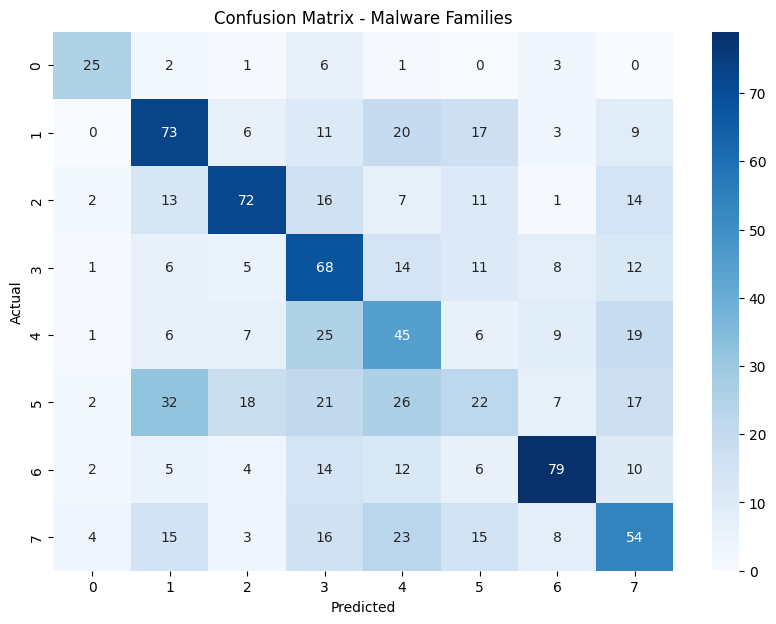

In [7]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Malware Families')
plt.show()

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Malware Families')
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.close()
